In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from tqdm.notebook import tqdm
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [8]:
df0404 = pd.read_csv("../data/labeledAndAnomaly/no_plug/0404.csv")
df0712 = pd.read_csv("../data/labeledAndAnomaly/no_plug/0712.csv")
df1703 = pd.read_csv("../data/labeledAndAnomaly/no_plug/1703.csv")

df1103 = pd.read_csv("../data/labeledAndAnomaly/partial_plug/1103.csv")
df1803 = pd.read_csv("../data/labeledAndAnomaly/partial_plug/1803.csv")
df2503 = pd.read_csv("../data/labeledAndAnomaly/partial_plug/2503.csv")
df2108_1 = pd.read_csv("../data/labeledAndAnomaly/partial_plug/2108-1.csv")

df1003 = pd.read_csv("../data/labeledAndAnomaly/plug/1003.csv")
df1112 = pd.read_csv("../data/labeledAndAnomaly/plug/1112.csv")
df1503 = pd.read_csv("../data/labeledAndAnomaly/plug/1503.csv")
df2108_2 = pd.read_csv("../data/labeledAndAnomaly/plug/2108-2.csv")

In [9]:
no_plug_dfs = [df0404, df0712, df1703]
partial_plug_dfs = [df1103, df1803, df2503, df2108_1]
plug_dfs = [df1003, df1112, df1503, df2108_2]

In [10]:
FINAL_FEATURES = [
    'rel_tot_dp_change', 
    'rel_ts_dp_change', 
    'rel_p_ts_dp_change', 
    'Relative_Ratio_Dev', 
    'anomaly_score',
    'Flow rate (Mean)'
]
WINDOW_SIZE = 60

In [11]:
def build_lstm_matrices(list_of_dfs, features, window_size=60):
    X_list = []
    y_list = []
    
    for df in list_of_dfs:
        data = df[features].values
        labels = df['label'].values
        
        for i in range(window_size, len(data)):
            window = data[i - window_size : i]
            target = labels[i]
            
            X_list.append(window)
            y_list.append(target)

    return np.array(X_list), np.array(y_list)

In [ ]:
all_runs = no_plug_dfs + plug_dfs + partial_plug_dfs

X_all, y_all = build_lstm_matrices(all_runs, FINAL_FEATURES, window_size=WINDOW_SIZE)

print(f"X_all Shape: {X_all.shape}")
print(f"y_all Shape: {y_all.shape}")

--- Data Extraction Complete ---
X_all Shape: (137264, 60, 6)
y_all Shape: (137264,)


In [ ]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, 
    test_size=0.15, 
    random_state=42, 
    stratify=y_all
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, 
    test_size=0.1764, 
    random_state=42, 
    stratify=y_trainval
)

print(f"Train Shape:      {X_train.shape}  (Labels: {len(y_train)})")
print(f"Validation Shape: {X_val.shape}  (Labels: {len(y_val)})")
print(f"Test Shape:       {X_test.shape}  (Labels: {len(y_test)})")

--- 70-15-15 Splitting ---
Train Shape:      (96092, 60, 6)  (Labels: 96092)
Validation Shape: (20582, 60, 6)  (Labels: 20582)
Test Shape:       (20590, 60, 6)  (Labels: 20590)


In [ ]:

n_samples_train, n_timesteps, n_features = X_train.shape
n_samples_val = X_val.shape[0]
n_samples_test = X_test.shape[0]

# Flatten 3D matrices down to 2D matrices so StandardScaler can read them
X_train_flat = X_train.reshape(-1, n_features)
X_val_flat   = X_val.reshape(-1, n_features)
X_test_flat  = X_test.reshape(-1, n_features)

# Fit and scale exclusively based on training data distributions
lstm_scaler = StandardScaler()
X_train_scaled_flat = lstm_scaler.fit_transform(X_train_flat)

# Transform validation and testing data 
X_val_scaled_flat   = lstm_scaler.transform(X_val_flat)
X_test_scaled_flat  = lstm_scaler.transform(X_test_flat)

# Reconstruct back into  3D window structures
X_train_scaled = X_train_scaled_flat.reshape(n_samples_train, n_timesteps, n_features)
X_val_scaled   = X_val_scaled_flat.reshape(n_samples_val, n_timesteps, n_features)
X_test_scaled  = X_test_scaled_flat.reshape(n_samples_test, n_timesteps, n_features)

joblib.dump(lstm_scaler, '../models/flow_model_scaler.joblib')


['../models/flow_model_scaler.joblib']

In [ ]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

BATCH_SIZE = 128

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print(f"Training Batches:   {len(train_loader)}")
print(f"Validation Batches: {len(val_loader)}")
print(f"Test Batches:       {len(test_loader)}")


--- DataLoaders Ready ---
Training Batches:   751
Validation Batches: 161
Test Batches:       161


In [ ]:
BATCH_SIZE = 128

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches per epoch: {len(train_loader)}")

Data is ready! Number of training batches per epoch: 751


In [ ]:
class HydraulicLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes):
        super(HydraulicLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
        )
        
        self.fc = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        # Initialize hidden and cell states with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # Forward pass through LSTM layer
        out, _ = self.lstm(x, (h0, c0))
        
        # Only need the hidden state of the last time step as it contains the summarized memory of the whole sequence
        last_time_step_output = out[:, -1, :]
        
        # Pass summary through classifier to get the final 4 output scores
        logits = self.fc(last_time_step_output)
        return logits

In [ ]:
INPUT_DIM = 6   
HIDDEN_DIM = 64  
NUM_LAYERS = 2   
NUM_CLASSES = 4  

model = HydraulicLSTM(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES)

criterion = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

HydraulicLSTM(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)


In [ ]:
device = torch.device('cpu')
model = model.to(device)

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, max_epochs, patience):
    device = torch.device('cpu')
    model = model.to(device)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_epoch = 0
    
    for epoch in range(max_epochs):
        current_lr = optimizer.param_groups[0]['lr']
        
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        
        # Create a dynamic text-based progress bar for training batches
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{max_epochs:02d} [Train] (LR: {current_lr:.6f})", leave=True)
        
        for batch_X, batch_y in train_bar:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += batch_y.size(0)
            correct_train += (predicted == batch_y).sum().item()
            
            batch_acc = (predicted == batch_y).sum().item() / batch_y.size(0)
            train_bar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{batch_acc*100:.1f}%"})
            
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        
        # Progress bar for validation batches
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{max_epochs:02d} [Valid]", leave=False)
        
        with torch.no_grad():
            for batch_X, batch_y in val_bar:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item() * batch_X.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += batch_y.size(0)
                correct_val += (predicted == batch_y).sum().item()
                
                val_bar.set_postfix({'loss': f"{loss.item():.4f}"})
                
        epoch_val_loss = val_loss / total_val
        epoch_val_acc = correct_val / total_val
        
        # Print final epoch summary statement
        print(f"Epoch [{epoch+1:02d}/{max_epochs:02d}] Summary:")
        print(f"[TRAIN] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc*100:.2f}%")
        print(f"[VALID] Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc*100:.2f}%")
        
        scheduler.step(epoch_val_loss)
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save(model.state_dict(), '../models/best_flow_rate_model.pth')
            print(f" New Best Val Loss! Weights saved to 'best_flow_rate_model.pth'")
        else:
            epochs_no_improve += 1
            print(f" No improvement in val loss for {epochs_no_improve} epoch(s).")
            
        print("=" * 70)
        
        if epochs_no_improve >= patience:
            print(f"\nEarly Stopping Triggered! No improvement for {patience} epochs.")
            print(f"Best configuration at Epoch {best_epoch} with Val Loss: {best_val_loss:.4f}")
            break
            
    # Load the best weights back into memory
    model.load_state_dict(torch.load('../models/best_flow_rate_model.pth'))
    print("\n best model configuration re-loaded into memory!")
    return model

In [23]:
best_model = train_model(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    max_epochs=100, 
    patience=15
)

Adaptive Training Loop started on: cpu



Epoch 01/100 [Train] (LR: 0.001000):   0%|          | 0/751 [00:00<?, ?it/s]

Epoch 01/100 [Valid]:   0%|          | 0/161 [00:00<?, ?it/s]

✨ Epoch [01/100] Summary:
   [TRAIN] Loss: 0.2512 | Acc: 91.17%
   [VALID] Loss: 0.1619 | Acc: 94.48%
 New Best Val Loss! Weights saved to 'best_flow_rate_model.pth'


Epoch 02/100 [Train] (LR: 0.001000):   0%|          | 0/751 [00:00<?, ?it/s]

...

Epoch 99/100 [Valid]:   0%|          | 0/161 [00:00<?, ?it/s]

✨ Epoch [99/100] Summary:
   [TRAIN] Loss: 0.0119 | Acc: 99.57%
   [VALID] Loss: 0.0145 | Acc: 99.48%
 New Best Val Loss! Weights saved to 'best_flow_rate_model.pth'


Epoch 100/100 [Train] (LR: 0.000001):   0%|          | 0/751 [00:00<?, ?it/s]

Epoch 100/100 [Valid]:   0%|          | 0/161 [00:00<?, ?it/s]

✨ Epoch [100/100] Summary:
   [TRAIN] Loss: 0.0119 | Acc: 99.56%
   [VALID] Loss: 0.0145 | Acc: 99.48%
 No improvement in val loss for 1 epoch(s).

🏆 Absolute best model configuration successfully re-loaded into memory!


In [ ]:
best_model.eval()

test_predictions = []
test_true_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        outputs = best_model(batch_X)
        
        _, predicted = torch.max(outputs, 1)
        
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(batch_y.numpy())

y_pred = np.array(test_predictions)
y_true = np.array(test_true_labels)


Running final evaluation on the hidden Test Set...
 Evaluation complete!



================ FINAL TEST SET REPORT ================
                      precision    recall  f1-score   support

    Class 0: Healthy     0.9945    0.9987    0.9966     10367
  Class 1: Mild Plug     0.9895    0.9661    0.9776      2331
Class 2: Severe Plug     0.9970    0.9984    0.9977      7337
  Class 3: Full Plug     0.9982    1.0000    0.9991       555

            accuracy                         0.9949     20590
           macro avg     0.9948    0.9908    0.9928     20590
        weighted avg     0.9949    0.9949    0.9949     20590



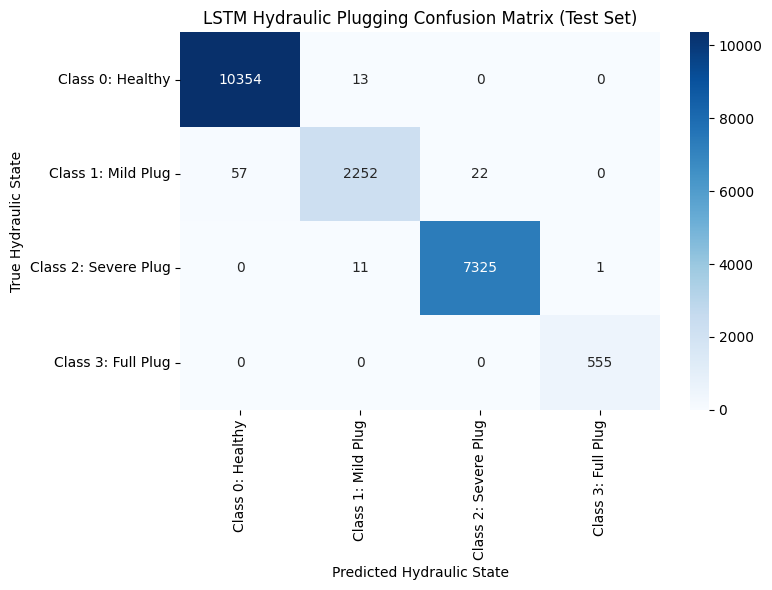

In [ ]:
target_names = ['Class 0: Healthy', 'Class 1: Mild Plug', 'Class 2: Severe Plug', 'Class 3: Full Plug']
print("\n================ FINAL TEST SET REPORT ================")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
print("=======================================================")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title('LSTM Hydraulic Plugging Confusion Matrix (Test Set)')
plt.ylabel('True Hydraulic State')
plt.xlabel('Predicted Hydraulic State')
plt.tight_layout()
plt.show()

In [ ]:
import copy
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

best_model.eval()
device = torch.device('cpu')

correct_baseline = 0
total_samples = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = best_model(batch_X)
        _, predicted = torch.max(outputs, 1)
        correct_baseline += (predicted.cpu() == batch_y).sum().item()
        total_samples += batch_y.size(0)

baseline_acc = correct_baseline / total_samples
print(f"Baseline Test Accuracy: {baseline_acc*100:.2f}%\n")

feature_names = ['rel_tot_dp_change', 'rel_ts_dp_change', 'rel_p_ts_dp_change', 'Relative_Ratio_Dev', 'Anomaly_Score']
importance_scores = {}

# Loop through each feature to evaluate its importance
for feat_idx, feat_name in enumerate(feature_names):
    # Create a copy of the test tensor so we don't break it
    X_test_perturbed = copy.deepcopy(X_test_t)
    
    # Extract the data for just this specific feature across all samples and time steps
    feat_data = X_test_perturbed[:, :, feat_idx].numpy()
    
    # Flatten, scramble the row order randomly, and reshape it back
    num_samples = feat_data.shape[0]
    shuffled_indices = np.random.permutation(num_samples)
    feat_data_shuffled = feat_data[shuffled_indices, :]
    
    # Shove the scrambled data back into our copied tensor
    X_test_perturbed[:, :, feat_idx] = torch.tensor(feat_data_shuffled, dtype=torch.float32)
    
    # Create a temporary loader for this corrupted dataset
    perturbed_dataset = torch.utils.data.TensorDataset(X_test_perturbed, y_test_t)
    perturbed_loader = torch.utils.data.DataLoader(perturbed_dataset, batch_size=128, shuffle=False)
    
    # Evaluate performance on the corrupted data
    correct_perturbed = 0
    with torch.no_grad():
        for batch_X, batch_y in perturbed_loader:
            batch_X = batch_X.to(device)
            outputs = best_model(batch_X)
            _, predicted = torch.max(outputs, 1)
            correct_perturbed += (predicted.cpu() == batch_y).sum().item()
            
    perturbed_acc = correct_perturbed / total_samples
    
    accuracy_drop = baseline_acc - perturbed_acc
    importance_scores[feat_name] = accuracy_drop
    print(f"Scrambling '{feat_name}' -> New Acc: {perturbed_acc*100:.2f}% | Drop: {accuracy_drop*100:.2f}%")

Baseline Test Accuracy: 99.49%

Scrambling 'rel_tot_dp_change' -> New Acc: 86.72% | Drop: 12.77%
Scrambling 'rel_ts_dp_change' -> New Acc: 75.01% | Drop: 24.48%
Scrambling 'rel_p_ts_dp_change' -> New Acc: 68.61% | Drop: 30.89%
Scrambling 'Relative_Ratio_Dev' -> New Acc: 79.97% | Drop: 19.53%
Scrambling 'Anomaly_Score' -> New Acc: 75.38% | Drop: 24.12%
Scrambling 'Flow rate (Mean)' -> New Acc: 69.25% | Drop: 30.25%


/var/folders/mn/hmhwf_5919qf62p9d6fjr1cw0000gn/T/ipykernel_40389/3418874953.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')


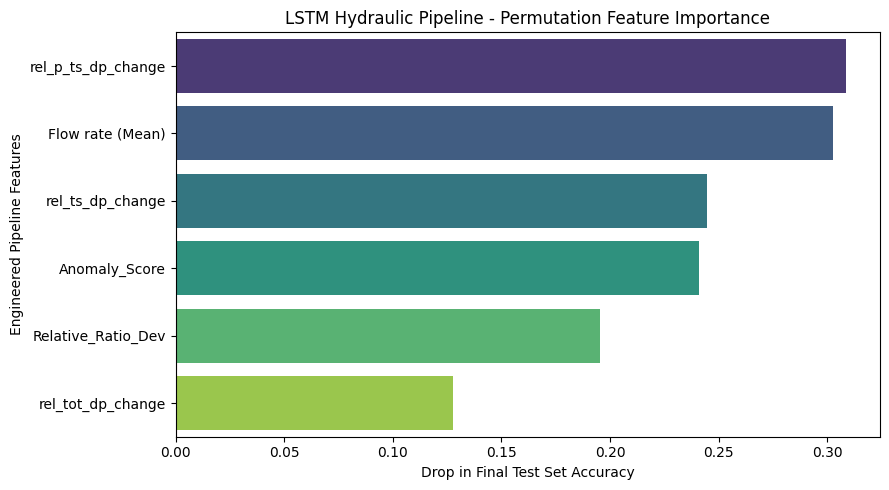

In [28]:
# Convert dictionary to a sorted DataFrame
df_importance = pd.DataFrame(list(importance_scores.items()), columns=['Feature', 'Importance'])
df_importance = df_importance.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('LSTM Hydraulic Pipeline - Permutation Feature Importance')
plt.xlabel('Drop in Final Test Set Accuracy')
plt.ylabel('Engineered Pipeline Features')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()